# Hotel Booking Status Prediction — ANN
**Target Variable:** `Reservation_Status` — 1 = Check-in · 2 = Cancelled · 3 = No-show

### Data Split
| Split | Source | Size | Role |
|---|---|---|---|
| Training | `train_encoded.csv` + 80% of `valid_encoded.csv` | ~29,690 rows | Model training |
| Validation | 80% of `valid_encoded.csv` (stratified) | ~2,199 rows | Early stopping & threshold tuning |
| Test | 20% of `valid_encoded.csv` (stratified) | ~550 rows | Final evaluation |


## 1. Install & Import

In [1]:
!pip install imbalanced-learn scikit-learn pandas numpy matplotlib seaborn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from collections import Counter
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report, confusion_matrix
)
from sklearn.utils import compute_class_weight
from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, Callback
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.losses import CategoricalCrossentropy

print(f"TensorFlow : {tf.__version__}")
print(f"Keras      : {tf.keras.__version__}")

TensorFlow : 2.19.0
Keras      : 3.13.2


## 2. Load Data

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
train_df = pd.read_csv('/content/drive/MyDrive/Hotel Revenue Prediction GCW/train_encoded.csv')
valid_df = pd.read_csv('/content/drive/MyDrive/Hotel Revenue Prediction GCW/valid_encoded.csv')

TARGET       = 'Reservation_Status'
DROP_COLS    = ['Reservation_id', TARGET]
FEATURE_COLS = [c for c in train_df.columns if c not in DROP_COLS]
NUM_CLASSES  = 3
TARGET_NAMES = ['Check-in', 'Cancelled', 'No-show']

print(f'train_encoded.csv : {len(train_df):,} rows x {len(FEATURE_COLS)} features')
print(f'valid_encoded.csv : {len(valid_df):,} rows x {len(FEATURE_COLS)} features')
print()
print('Class distribution — train_df:')
for cls, cnt in train_df[TARGET].value_counts().sort_index().items():
    print(f'  Class {cls}: {cnt:,}  ({cnt/len(train_df)*100:.1f}%)')
print()
print('Class distribution — valid_df:')
for cls, cnt in valid_df[TARGET].value_counts().sort_index().items():
    print(f'  Class {cls}: {cnt:,}  ({cnt/len(valid_df)*100:.1f}%)')

train_encoded.csv : 27,491 rows x 36 features
valid_encoded.csv : 2,749 rows x 36 features

Class distribution — train_df:
  Class 1: 21,235  (77.2%)
  Class 2: 4,134  (15.0%)
  Class 3: 2,122  (7.7%)

Class distribution — valid_df:
  Class 1: 1,610  (58.6%)
  Class 2: 741  (27.0%)
  Class 3: 398  (14.5%)


## 3. Split Validation Set → Val 80% + Test 20%
The validation dataset is split into two stratified portions:
- **val80** — added to the training data; used for early stopping and threshold tuning
- **test20** — held out entirely; only used for final evaluation


In [4]:
val80_df, test20_df = train_test_split(
    valid_df,
    test_size=0.2,
    random_state=42,
    stratify=valid_df[TARGET]
)

train_new_df = pd.concat([train_df, val80_df], ignore_index=True)

print('Split Summary')
print(f'  train_df              : {len(train_df):,} rows')
print(f'  val80 (80% of valid)  : {len(val80_df):,} rows')
print(f'  New training set      : {len(train_new_df):,} rows')
print(f'  test20 (20% of valid) : {len(test20_df):,} rows')
print()
print('Class distribution — new training set:')
for cls, cnt in train_new_df[TARGET].value_counts().sort_index().items():
    print(f'  Class {cls}: {cnt:,}  ({cnt/len(train_new_df)*100:.1f}%)')
print()
print('Class distribution — val80:')
for cls, cnt in val80_df[TARGET].value_counts().sort_index().items():
    print(f'  Class {cls}: {cnt:,}  ({cnt/len(val80_df)*100:.1f}%)')
print()
print('Class distribution — test20:')
for cls, cnt in test20_df[TARGET].value_counts().sort_index().items():
    print(f'  Class {cls}: {cnt:,}  ({cnt/len(test20_df)*100:.1f}%)')

X_train_new = train_new_df[FEATURE_COLS].values.astype(float)
y_train_new = train_new_df[TARGET].values - 1

X_val80  = val80_df[FEATURE_COLS].values.astype(float)
y_val80  = val80_df[TARGET].values - 1

X_test20 = test20_df[FEATURE_COLS].values.astype(float)
y_test20 = test20_df[TARGET].values - 1

Split Summary
  train_df              : 27,491 rows
  val80 (80% of valid)  : 2,199 rows
  New training set      : 29,690 rows
  test20 (20% of valid) : 550 rows

Class distribution — new training set:
  Class 1: 22,523  (75.9%)
  Class 2: 4,727  (15.9%)
  Class 3: 2,440  (8.2%)

Class distribution — val80:
  Class 1: 1,288  (58.6%)
  Class 2: 593  (27.0%)
  Class 3: 318  (14.5%)

Class distribution — test20:
  Class 1: 322  (58.5%)
  Class 2: 148  (26.9%)
  Class 3: 80  (14.5%)


## 4. Standardise & SMOTE
The scaler is fit on the new training set only and applied to val80 and test20.  
SMOTE is applied only to the training set to handle class imbalance.


In [5]:
scaler     = StandardScaler()
X_tr_s     = scaler.fit_transform(X_train_new)
X_val80_s  = scaler.transform(X_val80)
X_test20_s = scaler.transform(X_test20)

cw_arr        = compute_class_weight('balanced', classes=np.array([0,1,2]), y=y_train_new)
CLASS_WEIGHTS = dict(enumerate(cw_arr))
print('Class weights:', {k: round(v,4) for k,v in CLASS_WEIGHTS.items()})

smote = SMOTE(random_state=42, k_neighbors=5)
X_smote, y_smote = smote.fit_resample(X_tr_s, y_train_new)

y_smote_oh     = to_categorical(y_smote,     NUM_CLASSES)
y_train_new_oh = to_categorical(y_train_new, NUM_CLASSES)
y_val80_oh     = to_categorical(y_val80,     NUM_CLASSES)
y_test20_oh    = to_categorical(y_test20,    NUM_CLASSES)

print()
print(f'Before SMOTE : {Counter(y_train_new)}')
print(f'After  SMOTE : {Counter(y_smote)}')
print(f'Training shape after SMOTE : {X_smote.shape}')

Class weights: {0: np.float64(0.4394), 1: np.float64(2.0936), 2: np.float64(4.056)}

Before SMOTE : Counter({np.int64(0): 22523, np.int64(1): 4727, np.int64(2): 2440})
After  SMOTE : Counter({np.int64(0): 22523, np.int64(1): 22523, np.int64(2): 22523})
Training shape after SMOTE : (67569, 36)


## 5. F1-Macro Callback
A Keras `Callback` that computes `sklearn` F1-macro after each epoch on both  
the training set and val80, giving accurate per-epoch tracking.


In [6]:
class F1MacroCallback(Callback):

    def __init__(self, X_tr, y_tr, X_val, y_val):
        super().__init__()
        self.X_tr, self.y_tr   = X_tr, y_tr
        self.X_val, self.y_val = X_val, y_val
        self.best_val_f1       = 0.0
        self.hist_tr, self.hist_val = [], []

    def on_epoch_end(self, epoch, logs=None):
        y_pred_tr  = np.argmax(self.model.predict(self.X_tr,  verbose=0), axis=1)
        y_pred_val = np.argmax(self.model.predict(self.X_val, verbose=0), axis=1)

        f1_tr  = f1_score(self.y_tr,  y_pred_tr,  average='macro', zero_division=0)
        f1_val = f1_score(self.y_val, y_pred_val, average='macro', zero_division=0)

        self.hist_tr.append(f1_tr)
        self.hist_val.append(f1_val)
        if logs:
            logs['f1_tr']  = f1_tr
            logs['f1_val'] = f1_val
        if f1_val > self.best_val_f1:
            self.best_val_f1 = f1_val

        if (epoch + 1) % 10 == 0:
            print(f'  Epoch {epoch+1:>3} | Train F1={f1_tr:.4f}  Val80 F1={f1_val:.4f}')

## 6. ANN Architecture

| Hyperparameter | Value |
|---|---|
| Hidden layers | 3 |
| Neurons per layer | 192 |
| Activation | tanh |
| Dropout | 0.2 |
| L2 regularisation | 0.001 |
| Learning rate | 0.001 |
| Loss | CategoricalCrossentropy (label_smoothing=0.1) |
| Batch size | 256 |


In [7]:
def build_ann(input_dim, n_hidden=3, n_neurons=192, activation='tanh',
              dropout_rate=0.2, learning_rate=0.001, l2_lambda=0.001):
    model = Sequential(name='Hotel_ANN')
    model.add(Input(shape=(input_dim,)))
    for i in range(n_hidden):
        model.add(Dense(n_neurons, activation=activation,
                        kernel_regularizer=l2(l2_lambda),
                        name=f'dense_{i+1}'))
        model.add(BatchNormalization(name=f'bn_{i+1}'))
        model.add(Dropout(dropout_rate, name=f'drop_{i+1}'))
    model.add(Dense(NUM_CLASSES, activation='softmax', name='output'))
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss=CategoricalCrossentropy(label_smoothing=0.1),
        metrics=['accuracy']
    )
    return model

ann = build_ann(X_smote.shape[1])
ann.summary()

Model: "Hotel_ANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 192)            │         7,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 192)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (Dropout)                │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 192)            │        37,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 192)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_2 (Dropout)                │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 192)            │        37,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 192)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_3 (Dropout)                │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │           579 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 84,099 (328.51 KB)

 Trainable params: 82,947 (324.01 KB)

 Non-trainable params: 1,152 (4.50 KB)

## 7. Train ANN

In [8]:
f1_cb = F1MacroCallback(
    X_tr=X_smote,    y_tr=y_smote,
    X_val=X_val80_s, y_val=y_val80
)

es = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

history = ann.fit(
    X_smote, y_smote_oh,
    validation_data=(X_val80_s, y_val80_oh),
    epochs=100,
    batch_size=256,
    callbacks=[es, f1_cb],
    class_weight=CLASS_WEIGHTS,
    verbose=0
)

print(f'Best Val80 F1 : {f1_cb.best_val_f1:.4f}')

  Epoch  10 | Train F1=0.4489  Val80 F1=0.2898
  Epoch  20 | Train F1=0.5131  Val80 F1=0.3292
  Epoch  30 | Train F1=0.5462  Val80 F1=0.3473
  Epoch  40 | Train F1=0.5693  Val80 F1=0.3568
  Epoch  50 | Train F1=0.5872  Val80 F1=0.3684
  Epoch  60 | Train F1=0.6118  Val80 F1=0.3864
  Epoch  70 | Train F1=0.6048  Val80 F1=0.3946
  Epoch  80 | Train F1=0.6219  Val80 F1=0.3961
  Epoch  90 | Train F1=0.6179  Val80 F1=0.3944
  Epoch 100 | Train F1=0.6319  Val80 F1=0.4053
Restoring model weights from the end of the best epoch: 93.
Best Val80 F1 : 0.4122


## 8. Training History

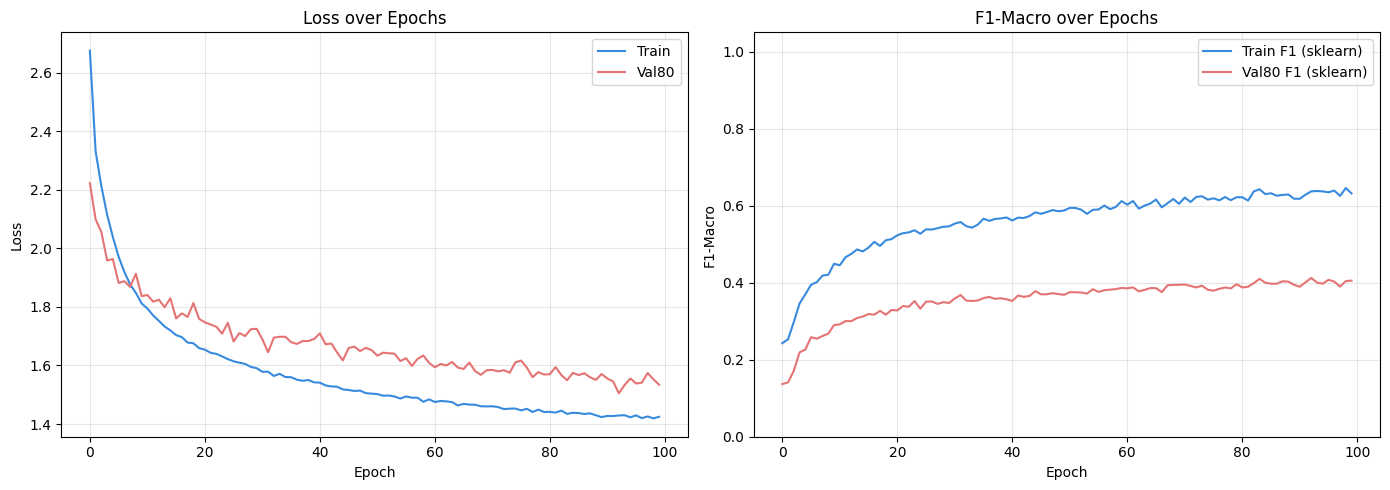

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train', color='#378ADD')
axes[0].plot(history.history['val_loss'], label='Val80', color='#E57373')
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(f1_cb.hist_tr,  label='Train F1 (sklearn)', color='#378ADD')
axes[1].plot(f1_cb.hist_val, label='Val80 F1 (sklearn)', color='#E57373')
axes[1].set_title('F1-Macro over Epochs')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('F1-Macro')
axes[1].set_ylim(0, 1.05)
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Per-Class Decision Threshold Tuning
Default softmax argmax under-predicts minority classes.  
A per-class threshold grid search on val80 improves minority class recall.


In [10]:
proba_tr     = ann.predict(X_tr_s,     verbose=0)
proba_val80  = ann.predict(X_val80_s,  verbose=0)
proba_test20 = ann.predict(X_test20_s, verbose=0)

best_f1, best_thresholds = 0.0, (0.5, 0.5, 0.5)
grid = np.arange(0.05, 0.95, 0.05)

for t0 in grid:
    for t1 in grid:
        for t2 in grid:
            adj = np.column_stack([proba_val80[:,0]/t0,
                                   proba_val80[:,1]/t1,
                                   proba_val80[:,2]/t2])
            f1 = f1_score(y_val80, np.argmax(adj, 1), average='macro', zero_division=0)
            if f1 > best_f1:
                best_f1 = f1
                best_thresholds = (t0, t1, t2)

t0, t1, t2 = best_thresholds
print(f'Optimal thresholds — Check-in: {t0:.2f}  Cancelled: {t1:.2f}  No-show: {t2:.2f}')

def apply_thresholds(proba, thresholds):
    t0, t1, t2 = thresholds
    adj = np.column_stack([proba[:,0]/t0, proba[:,1]/t1, proba[:,2]/t2])
    return np.argmax(adj, axis=1)

Optimal thresholds — Check-in: 0.05  Cancelled: 0.35  No-show: 0.60


## 10. Model Evaluation — All 5 Metrics

In [11]:
def full_eval(proba, y_true, y_oh, thresholds, label):
    y_pred = apply_thresholds(proba, thresholds)
    y_bin  = label_binarize(y_true, classes=[0, 1, 2])
    return {
        'Split'    : label,
        'Accuracy' : accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'Recall'   : recall_score(y_true, y_pred, average='macro', zero_division=0),
        'F1-macro' : f1_score(y_true, y_pred, average='macro', zero_division=0),
        'ROC-AUC'  : roc_auc_score(y_bin, proba, multi_class='ovr', average='macro'),
    }

m_tr  = full_eval(proba_tr,     y_train_new, y_train_new_oh, best_thresholds, 'Train')
m_v80 = full_eval(proba_val80,  y_val80,     y_val80_oh,     best_thresholds, 'Validation (val80)')
m_t20 = full_eval(proba_test20, y_test20,    y_test20_oh,    best_thresholds, 'Test (test20)')

results_df = pd.DataFrame([m_tr, m_v80, m_t20])

print('=' * 72)
print('  MODEL PERFORMANCE — ALL 5 METRICS')
print('=' * 72)
print(results_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
print('=' * 72)

  MODEL PERFORMANCE — ALL 5 METRICS
             Split  Accuracy  Precision  Recall  F1-macro  ROC-AUC
             Train    0.7982     0.6987  0.6927    0.6957   0.8755
Validation (val80)    0.7244     0.7200  0.7002    0.7091   0.8566
     Test (test20)    0.5236     0.3417  0.3460    0.3315   0.4997


## 11. Per-Class Report & Confusion Matrices

In [ ]:
y_pred_test20 = apply_thresholds(proba_test20, best_thresholds)

# Map numerical labels to TARGET_NAMES for better readability
true_labels_mapped = np.vectorize(lambda x: TARGET_NAMES[x])(y_test20)
predicted_labels_mapped = np.vectorize(lambda x: TARGET_NAMES[x])(y_pred_test20)

predictions_df = pd.DataFrame({
    'True_Reservation_Status': true_labels_mapped,
    'Predicted_Reservation_Status': predicted_labels_mapped,
    'Check-in_Prob': proba_test20[:, 0],
    'Cancelled_Prob': proba_test20[:, 1],
    'No-show_Prob': proba_test20[:, 2]
})

print('Predictions for Test (test20) Dataset:')
display(predictions_df.head(10))

  CLASSIFICATION REPORT — Train
              precision    recall  f1-score   support

    Check-in       0.86      0.87      0.87     22523
   Cancelled       0.51      0.50      0.51      4727
     No-show       0.72      0.71      0.71      2440

    accuracy                           0.80     29690
   macro avg       0.70      0.69      0.70     29690
weighted avg       0.80      0.80      0.80     29690

  CLASSIFICATION REPORT — Validation (val80)
              precision    recall  f1-score   support

    Check-in       0.75      0.80      0.77      1288
   Cancelled       0.62      0.56      0.59       593
     No-show       0.79      0.75      0.77       318

    accuracy                           0.72      2199
   macro avg       0.72      0.70      0.71      2199
weighted avg       0.72      0.72      0.72      2199

  CLASSIFICATION REPORT — Test (test20)
              precision    recall  f1-score   support

    Check-in       0.61      0.79      0.69       322
   Cancelled

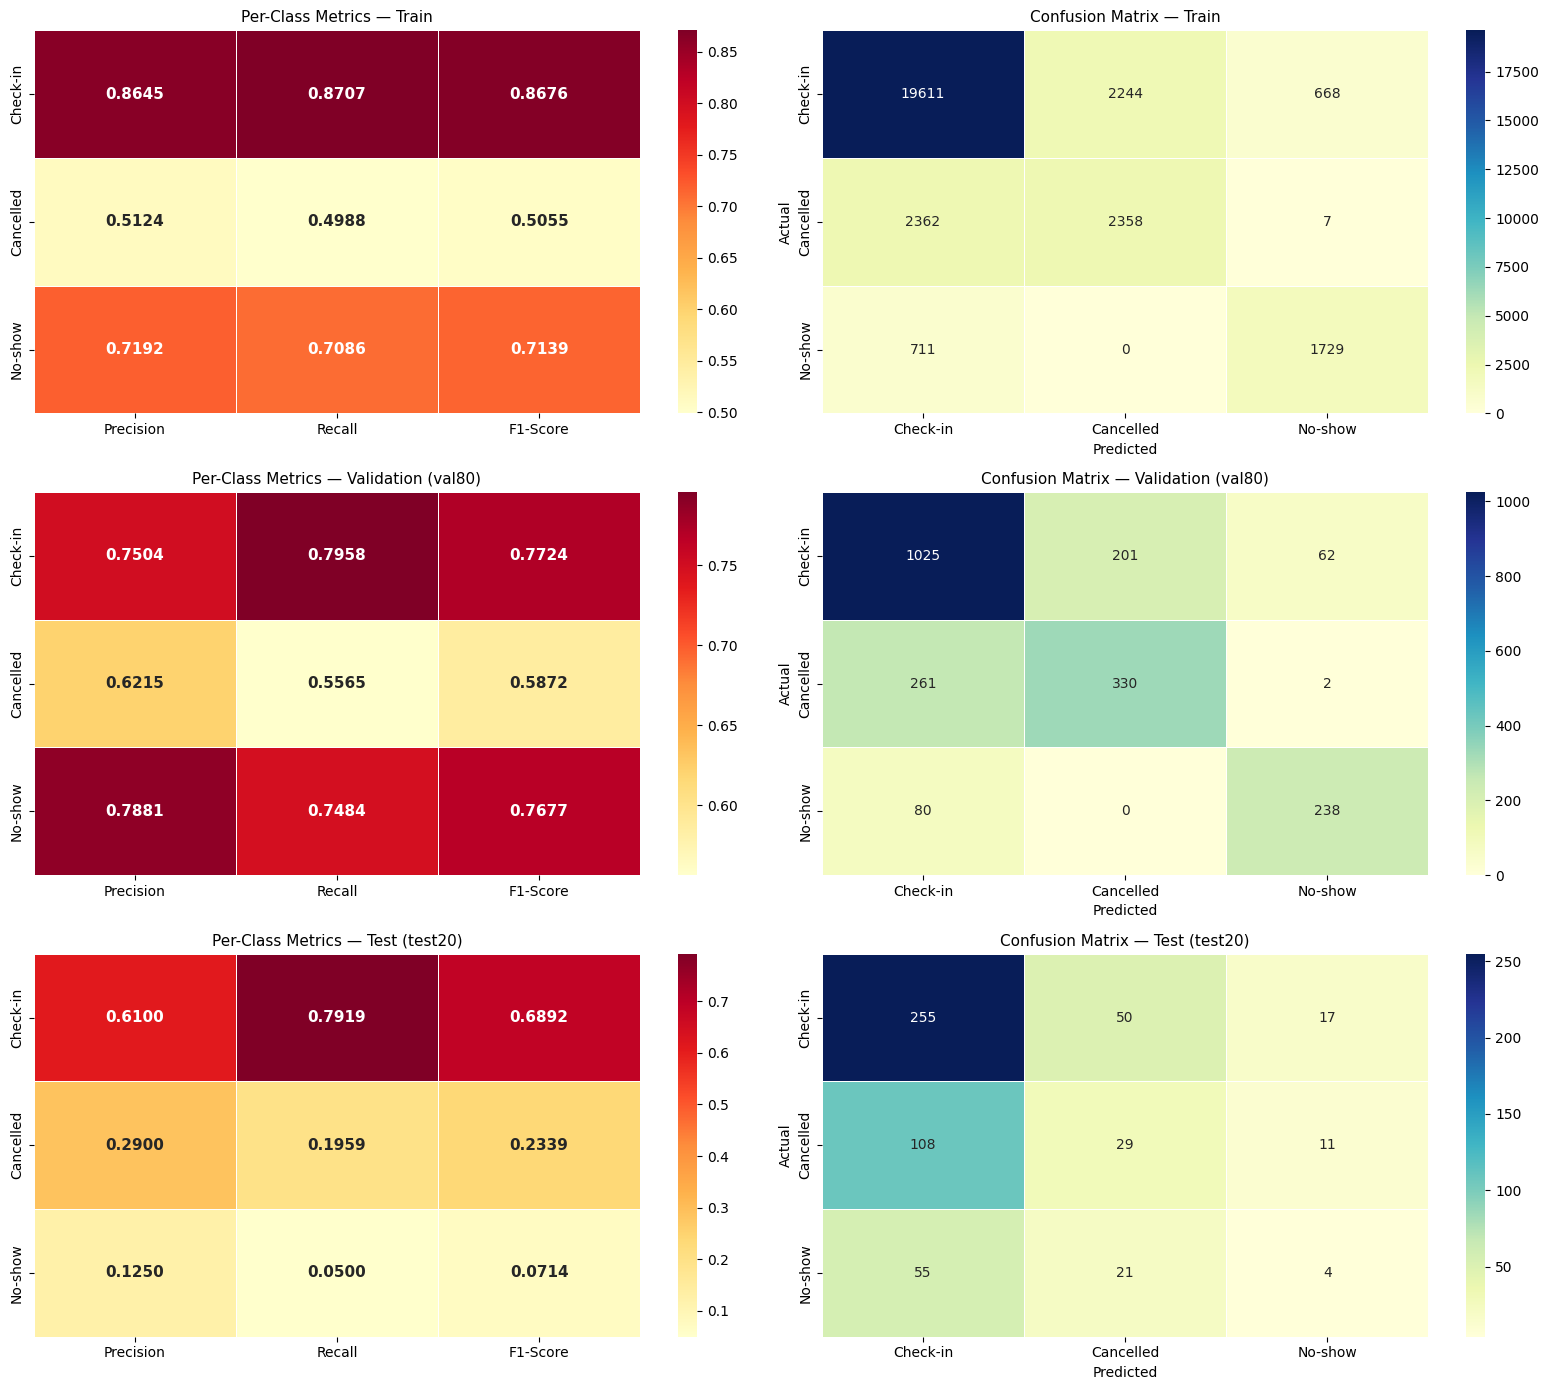

In [12]:
fig, axes = plt.subplots(3, 2, figsize=(16, 14))

splits = [
    (proba_tr,     y_train_new, 'Train'),
    (proba_val80,  y_val80,     'Validation (val80)'),
    (proba_test20, y_test20,    'Test (test20)'),
]

for row_idx, (proba, y_true, label) in enumerate(splits):
    y_pred = apply_thresholds(proba, best_thresholds)

    print(f'{"="*58}')
    print(f'  CLASSIFICATION REPORT — {label}')
    print(f'{"="*58}')
    print(classification_report(y_true, y_pred, target_names=TARGET_NAMES, zero_division=0))

    per_cls = pd.DataFrame({
        'Precision': precision_score(y_true, y_pred, average=None, zero_division=0),
        'Recall'   : recall_score(y_true, y_pred, average=None, zero_division=0),
        'F1-Score' : f1_score(y_true, y_pred, average=None, zero_division=0),
    }, index=TARGET_NAMES)

    sns.heatmap(per_cls, annot=True, fmt='.4f', cmap='YlOrRd',
                linewidths=0.5, annot_kws={'size': 11, 'weight': 'bold'},
                ax=axes[row_idx, 0])
    axes[row_idx, 0].set_title(f'Per-Class Metrics — {label}', fontsize=11)

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
                xticklabels=TARGET_NAMES, yticklabels=TARGET_NAMES,
                linewidths=0.5, ax=axes[row_idx, 1])
    axes[row_idx, 1].set_title(f'Confusion Matrix — {label}', fontsize=11)
    axes[row_idx, 1].set_xlabel('Predicted')
    axes[row_idx, 1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

## 12. Predict on Test datset


In [13]:
# @title New Test Dataset Path
NEW_DATASET_PATH = "/content/drive/MyDrive/Hotel Revenue Prediction GCW/test_encoded.csv"

In [14]:
try:
    new_df = pd.read_csv(NEW_DATASET_PATH)
    print(f'Successfully loaded new dataset from {NEW_DATASET_PATH}: {len(new_df):,} rows')

    # Check if target column exists, remove if it does (shouldn't for unseen data)
    if TARGET in new_df.columns:
        print(f"Warning: '{TARGET}' column found in new dataset. It will be ignored for prediction.")
        X_new = new_df[FEATURE_COLS].values.astype(float)
    else:
        X_new = new_df[FEATURE_COLS].values.astype(float)

    # Scale the new data using the previously fitted scaler
    X_new_s = scaler.transform(X_new)

    # Get probability predictions from the ANN model
    proba_new = ann.predict(X_new_s)

    # Apply optimal thresholds to get final predictions
    y_pred_new = apply_thresholds(proba_new, best_thresholds)

    # Map numerical predictions to TARGET_NAMES
    predicted_labels_new = np.vectorize(lambda x: TARGET_NAMES[x])(y_pred_new)

    # Create a DataFrame for predictions
    predictions_on_new_data_df = pd.DataFrame({
        'Predicted_Reservation_Status': predicted_labels_new,
        'Check-in_Prob': proba_new[:, 0],
        'Cancelled_Prob': proba_new[:, 1],
        'No-show_Prob': proba_new[:, 2]
    })

    # Display predictions, potentially alongside relevant original features
    display(new_df.head(10).merge(predictions_on_new_data_df.head(10), left_index=True, right_index=True, how='left'))
    print('\nFirst 10 predictions on the new dataset:')
    display(predictions_on_new_data_df.head(10))

except FileNotFoundError:
    print(f"Error: The file at '{NEW_DATASET_PATH}' was not found. Please double-check the path.")
except KeyError as e:
    print(f"Error: One or more required feature columns are missing from the new dataset: {e}. Please ensure the new dataset has the same feature columns as the training data.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Successfully loaded new dataset from /content/drive/MyDrive/Hotel Revenue Prediction GCW/test_encoded.csv: 4,318 rows
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step


,Reservation_id,Age,Adults,Children,Babies,Visted_Previously,Previous_Cancellations,Required_Car_Parking,Use_Promotion,Discount_Rate,...,Meal_Type_FB,Meal_Type_HB,Deposit_type_Non-Refundable,Deposit_type_Refundable,Booking_channel_Direct,Booking_channel_Online,Predicted_Reservation_Status,Check-in_Prob,Cancelled_Prob,No-show_Prob
0,62931593,52,3,3,0,0,0,1,1,10,...,0,1,0,0,1,0,Check-in,0.096251,0.143052,0.760697
1,70586099,47,2,1,0,0,0,0,0,0,...,1,0,0,0,0,1,Cancelled,0.053628,0.829938,0.116434
2,4230648,28,2,2,0,0,0,0,1,5,...,0,0,0,0,0,0,Check-in,0.393393,0.156382,0.450226
3,25192322,65,1,3,2,0,0,1,1,10,...,1,0,0,0,0,1,Check-in,0.194568,0.606128,0.199304
4,80931528,45,3,1,0,0,0,0,0,0,...,0,0,0,1,0,0,Check-in,0.471119,0.386073,0.142808
5,64700386,65,2,2,1,0,0,1,1,5,...,0,0,0,0,1,0,No-show,0.053175,0.049613,0.897212
6,16938050,26,4,2,0,0,0,1,1,5,...,0,0,0,0,0,0,Check-in,0.177981,0.705363,0.116656
7,90487908,45,3,2,1,0,0,0,1,10,...,1,0,0,0,0,1,Check-in,0.079578,0.310042,0.610380
8,5595445,27,1,1,0,0,0,0,1,30,...,1,0,1,0,1,0,Check-in,0.269053,0.569614,0.161333
9,17502557,40,3,2,1,0,0,0,0,0,...,1,0,0,0,0,0,Cancelled,0.075665,0.843275,0.081060



First 10 predictions on the new dataset:


,Predicted_Reservation_Status,Check-in_Prob,Cancelled_Prob,No-show_Prob
0,Check-in,0.096251,0.143052,0.760697
1,Cancelled,0.053628,0.829938,0.116434
2,Check-in,0.393393,0.156382,0.450226
3,Check-in,0.194568,0.606128,0.199304
4,Check-in,0.471119,0.386073,0.142808
5,No-show,0.053175,0.049613,0.897212
6,Check-in,0.177981,0.705363,0.116656
7,Check-in,0.079578,0.310042,0.610380
8,Check-in,0.269053,0.569614,0.161333
9,Cancelled,0.075665,0.843275,0.081060


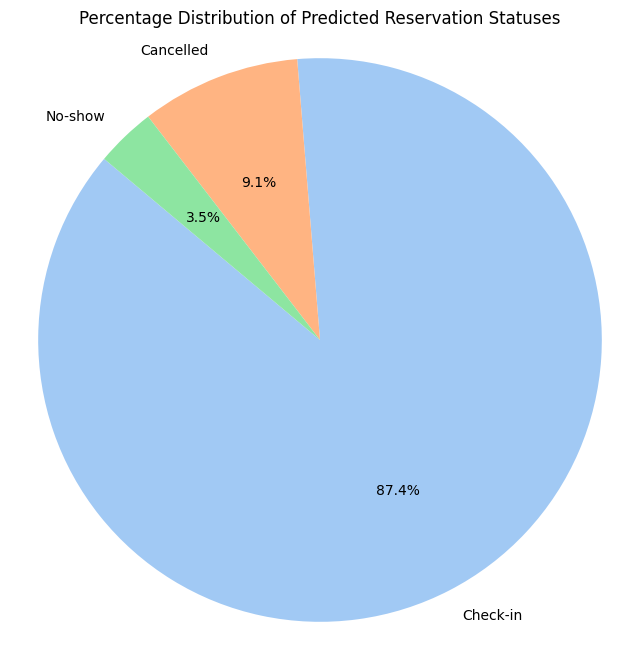

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the percentage distribution of predicted reservation statuses
status_counts = predictions_on_new_data_df['Predicted_Reservation_Status'].value_counts(normalize=True) * 100

plt.figure(figsize=(8, 8))
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Percentage Distribution of Predicted Reservation Statuses')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()